### NYC Taxi Trip Duration
- Predict the NYC Taxi Trip Duration - Data Science Project

In [1]:
!pip install -q opendatasets

import opendatasets as od

url = "https://www.kaggle.com/datasets/yasserh/nyc-taxi-trip-duration"
od.download(url)


ModuleNotFoundError: No module named 'cgi'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

import os

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.feature_selection import mutual_info_regression, RFECV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
base_dir = r"D:\UNV\02_DS\Project\NYC.csv"

if not os.path.exists(base_dir):
    base_dir = [d for d in os.listdir("/content") if "nyc" in d.lower()][0]
    base_dir = os.path.join("/content", base_dir)

# 3) Load dataset
csv_path = os.path.join(base_dir)

df = pd.read_csv(csv_path)

# 4) Basic checks
print(df.shape)
df.head()

(1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,1458644.0,1.534950,0.498777,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,1458644.0,1.664530,1.314242,0.000000,1.000000,1.000000,2.000000,9.000000e+00
pickup_longitude,1458644.0,-73.973486,0.070902,-121.933342,-73.991867,-73.981743,-73.967331,-6.133553e+01
pickup_latitude,1458644.0,40.750921,0.032881,34.359695,40.737347,40.754101,40.768360,5.188108e+01
dropoff_longitude,1458644.0,-73.973416,0.070643,-121.933304,-73.991325,-73.979752,-73.963013,-6.133553e+01
dropoff_latitude,1458644.0,40.751800,0.035891,32.181141,40.735885,40.754524,40.769810,4.392103e+01
trip_duration,1458644.0,959.492273,5237.431724,1.000000,397.000000,662.000000,1075.000000,3.526282e+06


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


## Step 1: Data Tidying & Data Cleaning Report

### 1. Type Corrections
We converted the `pickup_datetime` and `dropoff_datetime` columns from object strings to **datetime objects**. This was a fundamental step to enable time-series analysis and to extract temporal features such as hours and days of the week, which are critical predictors for trip duration.

### 2. Basic Cleansing & Duplicate Removal
We performed a check for redundant data and removed all exact duplicates to prevent the model from being biased toward repeated observations.

### 3. Handling Inconsistent Entries (Outlier Management)
To ensure data integrity, we applied the following filters:
* **Temporal Filtering:** Trips shorter than 1 minute or longer than 3 hours were removed, as they often represent system errors or stationary taxis rather than actual trips.
* **Geographical Filtering:** We restricted the coordinates to the NYC bounding box. Any coordinates outside this range were treated as GPS noise.
* **Spatial Validation:** By constructing the `distance_km` feature using the **Haversine Formula**, we identified and removed trips with zero distance (which are logically invalid for duration prediction).

### 4. Imputation Techniques
For missing values in the `passenger_count` column, we applied **Mode Imputation**. We chose the mode (most frequent value) because the number of passengers is a discrete, categorical-like variable, and using the mean would result in illogical decimal values (e.g., 1.5 passengers).

### 5. Data Tidying with Pivot Tables
We utilized **Pivot Tables** to restructure the data and verify its cleanliness. By aggregating the average trip duration by hour and day, we ensured that the cleaned dataset reflects realistic traffic patterns (e.g., higher durations during rush hours), confirming that our cleaning process preserved the essential characteristics of the data.

In [6]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
934418,id2932114,2,2016-06-29 18:33:06,2016-06-29 19:14:54,1,-73.78344,40.64864,-73.956787,40.683289,N,2508


In [7]:
# --- Step 2: Data Tidying & Data Cleaning ---

# [A] Type Corrections
# Converting date columns from strings to datetime objects for time-series analysis
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

# Data Type Enforcement: Convert coordinate columns to numeric (float)
# This prevents errors during mathematical calculations (like Haversine)
cols_to_fix = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove rows that became NaN during numeric conversion to maintain data quality
df.dropna(subset=cols_to_fix, inplace=True)

# [B] Feature Construction: Calculating Trip Distance
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculates the great-circle distance between two points
    on the Earth using the Haversine formula.
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # Result in Kilometers (Earth radius = 6371km)

# Apply the function to create a new distance column
df['distance_km'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# [C] Basic Cleansing
# Removing exact duplicate rows to avoid model bias
df.drop_duplicates(inplace=True)

# [D] Handling Inconsistent Entries & Outliers
# Ensure trip_duration is numeric before filtering
df['trip_duration'] = pd.to_numeric(df['trip_duration'], errors='coerce')

# 1. Temporal Filtering: Remove trips shorter than 1 minute or longer than 3 hours
df = df[(df['trip_duration'] > 60) & (df['trip_duration'] < 10800)]

# 2. Geographical Filtering: Restrict coordinates to the NYC metropolitan area
df = df[df['pickup_longitude'].between(-74.25, -73.70)]
df = df[df['pickup_latitude'].between(40.47, 40.92)]

# 3. Spatial Validation: Remove trips with zero distance or unrealistic lengths (>100km)
df = df[(df['distance_km'] > 0.1) & (df['distance_km'] < 100)]

# [E] Imputation: Handling Missing Values
# Fill missing passenger counts with the Mode (Most frequent value)
if df['passenger_count'].isnull().sum() > 0:
    df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True)

# [F] Data Tidying & Structural Analysis
# Extract hour and day name for granular analysis
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day_name()

# Create a Pivot Table to analyze average duration per hour across different days
# This helps verify if the cleaned data follows realistic traffic patterns
cleaning_summary_pivot = df.pivot_table(
    index='pickup_hour',
    columns='pickup_day',
    values='trip_duration',
    aggfunc='mean'
)

# Final Output Status
print("Data Cleaning Process Finished Successfully.")
print(f"Final records count: {df.shape[0]}")

Data Cleaning Process Finished Successfully.
Final records count: 1440222


In [8]:
cleaning_summary_pivot

pickup_day,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
pickup_hour,,,,,,,
0,804.441190,725.887524,836.563582,801.123092,749.004355,747.939455,741.567904
1,746.881107,705.079041,768.025036,777.267619,694.157939,697.842250,694.795918
2,705.127676,699.155364,727.383751,712.808002,691.482253,693.317687,654.787372
3,706.567776,726.207297,711.761977,716.745602,716.001988,679.227503,689.209768
4,779.973463,772.164894,745.478388,732.164046,733.456296,748.526457,721.829388
5,746.230579,745.077984,789.018916,770.486670,692.590345,669.022564,654.244748
6,689.786706,693.498108,716.131558,735.149644,669.443570,650.801930,648.905108
7,763.195785,800.736428,633.951573,654.083095,780.173634,780.564250,775.314515
8,854.668196,883.619434,630.310881,593.029142,892.476582,882.706661,874.451558


In [9]:
print(f"Min hours by Day{cleaning_summary_pivot.min()}, \n=============\nMax hours by Day{ cleaning_summary_pivot.max()}")

Min hours by Daypickup_day
Friday       689.786706
Monday       693.498108
Saturday     630.310881
Sunday       593.029142
Thursday     669.443570
Tuesday      650.801930
Wednesday    648.905108
dtype: float64, 
Max hours by Daypickup_day
Friday       1065.383401
Monday        915.194772
Saturday      853.947030
Sunday        891.329754
Thursday     1100.509508
Tuesday       983.658083
Wednesday    1069.875115
dtype: float64


In [10]:
# --- Validation & Sanity Checks ---
print("1. Checking for Missing Values:")
print(df.isnull().sum())
print("-" * 30)

print("2. Checking for Duplicates:")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

1. Checking for Missing Values:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
distance_km           0
pickup_hour           0
pickup_day            0
dtype: int64
------------------------------
2. Checking for Duplicates:
Total Duplicate Rows: 0


In [11]:
print("3. Checking Coordinate Ranges (Should be within NYC):")
print(f"Latitude Range:  {df['pickup_latitude'].min()} to {df['pickup_latitude'].max()}")
print(f"Longitude Range: {df['pickup_longitude'].min()} to {df['pickup_longitude'].max()}")
print("-" * 30)

print("4. Checking Trip Logic (Should be > 1 min and > 0.1 km):")
print(f"Minimum Duration: {df['trip_duration'].min()} seconds")
print(f"Minimum Distance: {df['distance_km'].min():.2f} km")
print("-" * 30)

print("5. Data Types Verification:")
print(df[['pickup_datetime', 'distance_km', 'passenger_count']].dtypes)

3. Checking Coordinate Ranges (Should be within NYC):
Latitude Range:  40.50629425048828 to 40.91659927368164
Longitude Range: -74.23101043701173 to -73.70709991455078
------------------------------
4. Checking Trip Logic (Should be > 1 min and > 0.1 km):
Minimum Duration: 61 seconds
Minimum Distance: 0.10 km
------------------------------
5. Data Types Verification:
pickup_datetime    datetime64[ns]
distance_km               float64
passenger_count             int64
dtype: object


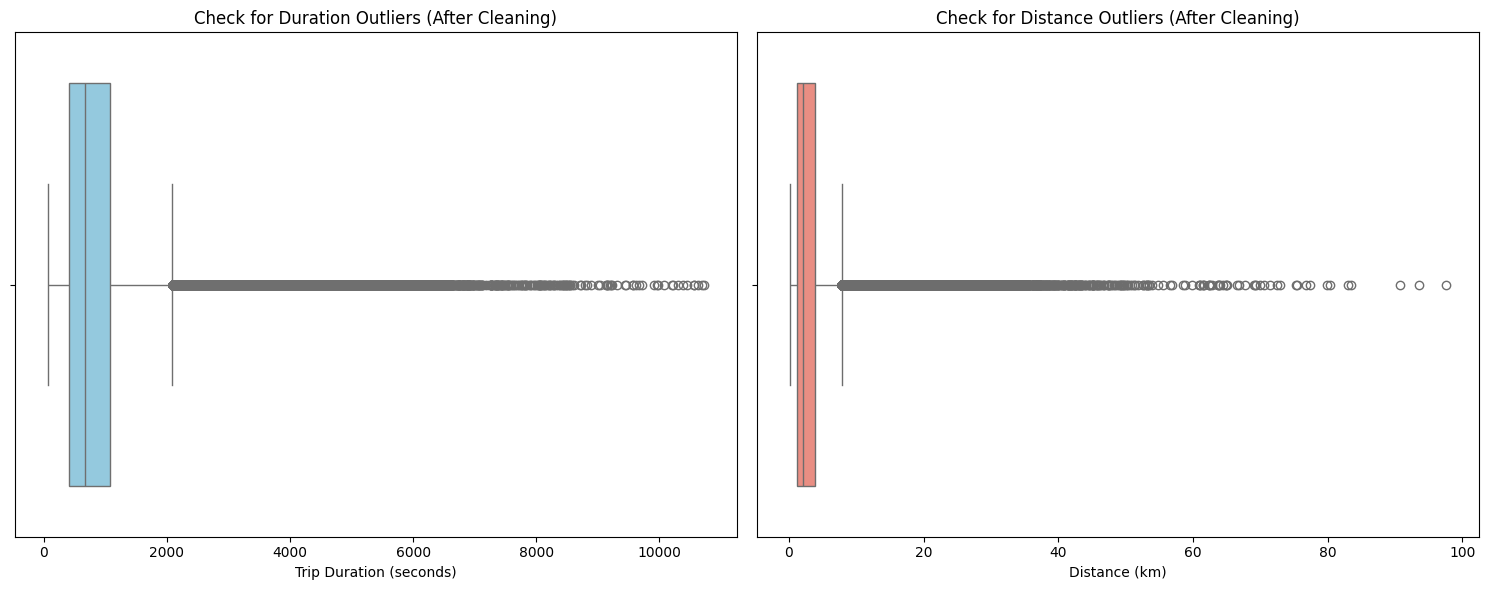

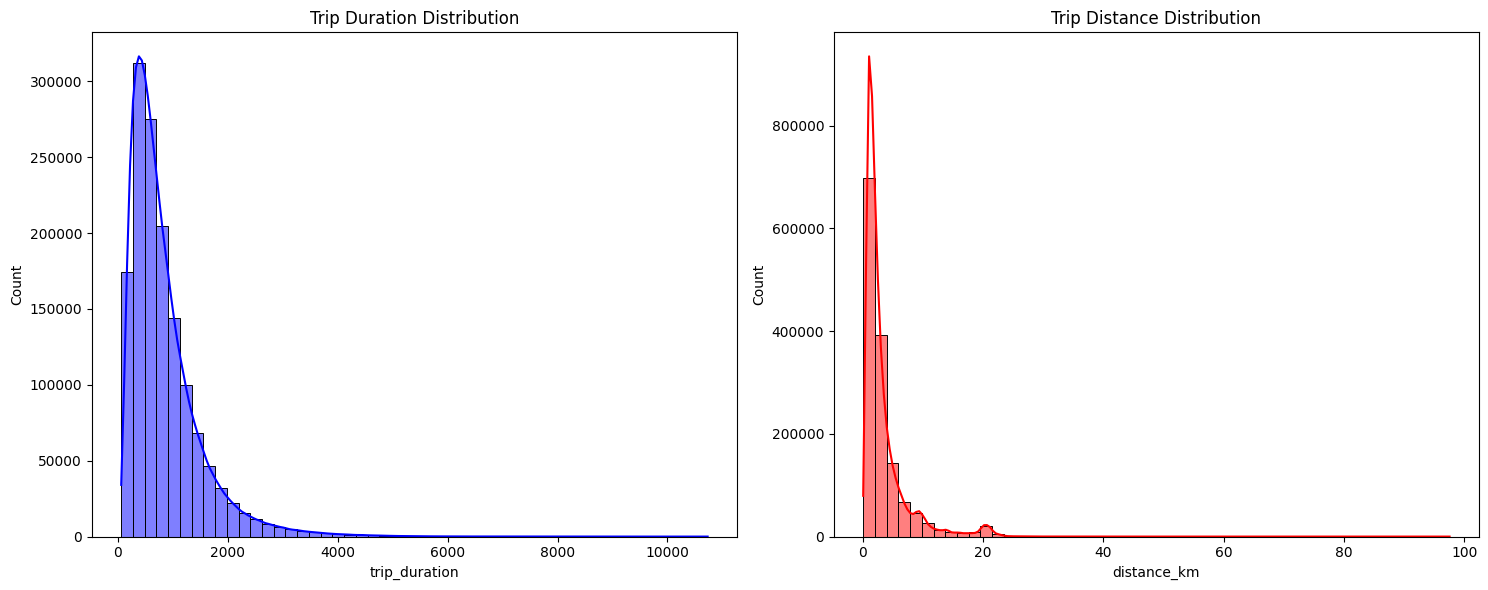

In [12]:
# Create a figure with 2 subplots (one for Duration, one for Distance)
plt.figure(figsize=(15, 6))

# 1. Boxplot for Trip Duration
plt.subplot(1, 2, 1)
sns.boxplot(x=df['trip_duration'], color='skyblue')
plt.title('Check for Duration Outliers (After Cleaning)')
plt.xlabel('Trip Duration (seconds)')

# 2. Boxplot for Trip Distance
plt.subplot(1, 2, 2)
sns.boxplot(x=df['distance_km'], color='salmon')
plt.title('Check for Distance Outliers (After Cleaning)')
plt.xlabel('Distance (km)')

plt.tight_layout()
plt.show()

# 3. Histogram to see the distribution of cleaned data
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['trip_duration'], bins=50, kde=True, color='blue')
plt.title('Trip Duration Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['distance_km'], bins=50, kde=True, color='red')
plt.title('Trip Distance Distribution')

plt.tight_layout()
plt.show()

## Feature Extraction --> ***Anas***

In [13]:
df.sample(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day
504514,id3407129,2,2016-01-19 11:40:02,2016-01-19 11:48:58,1,-73.971649,40.763500,-73.983452,40.781330,N,536,2.217769,11,Tuesday
1052901,id2734105,2,2016-04-14 21:15:22,2016-04-14 21:24:49,2,-73.988647,40.748280,-74.005829,40.740341,N,567,1.695363,21,Thursday
682730,id3065376,1,2016-04-26 21:43:01,2016-04-26 21:44:44,1,-73.967278,40.761265,-73.960197,40.770206,N,103,1.159353,21,Tuesday


### Rush Hour Feature
This feature checks if the trip happened during peak traffic hours (morning or evening).  
It helps the model understand traffic impact on trip duration.

In [14]:
# df['rush_hour'] = df['pickup_hour'].apply(lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 19) else 0)

#### Rush Hour and Congestion Analysis

| Feature | Time Window | Rationale | Data-Driven Insight |
|---------|-------------|-----------|-------------------|
| **afternoon_peak** | 14–16 | True peak congestion period | Pivot table showed 14–16 as genuine peak (~1000–1023s avg) |
| **midday_busy** | 10–15 | Extended midday congestion window | Broader coverage of daytime traffic (10–15 range) |
| **evening_rush** | 17–21 | Evening commute (deprecated) | Declining phase; NOT the actual peak—already falling from afternoon max |

#### Key Findings

- **Weekday vs Weekend Contrast:** Weekday patterns show clear morning and afternoon peaks; weekends have flatter, elevated evening durations
- **Thursday/Friday Effect:** Thu/Fri consistently ~15% longer than Mon/Tue at same hour
- **Why Not 17–21?** Pivot analysis revealed this window is already in the descending phase; 14–16 captures the true congestion maximum
- **Hour 10 Observation:** Still shows ~925s average—justifies extending morning window to include it

In [15]:
# ── Temporal Feature Engineering ──────────────────────────────────────────────
# Based on empirical analysis of avg trip duration from pivot table:
#   - Weekday peak congestion:  14–16  (~1000–1023s avg)
#   - Weekday morning traffic:   7–10  (~800–920s avg)
#   - Weekend pattern: opposite shape — evening stays elevated, morning is fast
#   - Thursday/Friday consistently ~15% longer than Mon/Tue at same hour

# 1. Weekend flag
df['is_weekend'] = (df['pickup_datetime'].dt.dayofweek >= 5).astype(int)
is_weekday = ~df['is_weekend'].astype(bool)

# 2. Day of week (0=Mon ... 6=Sun) — captures Thu/Fri effect pivot table revealed
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek

# 3. Data-driven congestion windows (from pivot table, NOT assumptions)
df['afternoon_peak']  = (is_weekday & df['pickup_hour'].between(14, 16)).astype(int)

# 4. DROP the old rush_hour — it was pointing at 17–21 which pivot showed
#    is already the DECLINING phase, not the peak
#    hour_sin + hour_cos + day_of_week replace it more faithfully

# 5. Sanity check — print mean duration per new flag to validate
print("Morning Rush mean duration (seconds):")
print("\nAfternoon Peak mean duration (seconds):")
print(df.groupby('afternoon_peak')['trip_duration'].mean().to_string())
print("\nWeekend mean duration (seconds):")
print(df.groupby('is_weekend')['trip_duration'].mean().to_string())
print("\nDay of Week mean duration (seconds):")
print(df.groupby('day_of_week')['trip_duration'].mean().to_string())

Morning Rush mean duration (seconds):

Afternoon Peak mean duration (seconds):
afternoon_peak
0     823.493468
1    1010.736442

Weekend mean duration (seconds):
is_weekend
0    868.877502
1    776.317411

Day of Week mean duration (seconds):
day_of_week
0    815.551214
1    860.560675
2    884.636405
3    903.248726
4    872.714970
5    783.368209
6    768.339055


In [16]:
# Data says peak congestion is 14-16 on weekdays, not 17-22
is_weekday = ~df['is_weekend'].astype(bool)

df['afternoon_peak'] = (is_weekday & df['pickup_hour'].between(14, 16)).astype(int)

### Trip Direction
This feature calculates the direction of the trip using pickup and dropoff coordinates.  
It may help capture movement patterns across the city.  
It is computed by taking the arctangent (atan2) of the difference in latitude (Y-axis) and longitude (X-axis) between dropoff and pickup points to obtain the trip angle.


In [17]:
df['direction'] = np.arctan2(
    df['dropoff_latitude'] - df['pickup_latitude'],
    df['dropoff_longitude'] - df['pickup_longitude']
)

### Average Speed
This feature estimates the trip speed (km/h) based on distance and duration.  
It helps identify abnormal trips and traffic conditions.

In [18]:
df['speed_kmh'] = df['distance_km'] / (df['trip_duration'] / 3600)

##### Speed Feature (For Analysis Only)

In this step, we calculate the average speed of each trip using distance and trip duration.

However, this feature is not used for model training.

The reason is that speed is calculated using the target variable (trip_duration). This creates a problem called data leakage, where the model indirectly gets access to the answer it is supposed to predict.

If we include speed as a feature, the model can easily infer the trip duration, leading to unrealistically high performance that does not reflect real-world behavior.

Instead, we use this feature for:
- Data Cleaning: to detect and remove unrealistic trips (e.g., extremely high or very low speeds)
- Exploratory Data Analysis (EDA): to better understand traffic patterns and trip behavior

This ensures that our model remains fair, realistic, and generalizable.

In [19]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh
817321,id0323913,1,2016-05-06 01:32:53,2016-05-06 01:45:26,1,-73.991013,40.750523,-73.971283,40.794857,N,753,5.202193,1,Friday,0,4,0,1.152093,24.871042


### Time Features
We extract if the trip is on a weekend and the month of the trip.  
This helps capture seasonal and weekly patterns.

In [20]:
# df['is_weekend'] = df['pickup_datetime'].dt.dayofweek >= 5
df['month'] = df['pickup_datetime'].dt.month

### Distance per Passenger
This feature divides trip distance by number of passengers.  
It may reflect ride-sharing patterns or trip efficiency.

In [21]:
df['distance_per_passenger'] = np.where(
    df['passenger_count'] > 0,
    df['distance_km'] / df['passenger_count'],
    0
)
#df['distance_per_passenger'] = df['distance_km'] / df['passenger_count']

### Log Transformation of Duration
We apply log transformation to reduce Skewed Distribution in trip duration.  
The goal is removing outliers.

In [22]:
df['log_trip_duration'] = np.log1p(df['trip_duration'])

### Location Clustering (KMeans)

In this step, we apply clustering on the pickup and dropoff coordinates to group similar locations into clusters.

Instead of using raw latitude and longitude values directly, we transform them into cluster labels. This helps simplify the spatial information and makes it easier for the model to understand location-based patterns.

The main idea is that nearby locations usually share similar traffic conditions and travel behavior. For example, trips starting in the same area (like city center or airport) often have similar durations.

By grouping coordinates into clusters, we allow the model to learn:
- differences between regions
- traffic behavior in each area
- patterns related to specific zones

This approach improves model performance because it reduces noise in raw coordinates and captures meaningful geographic structure in the data.

In [23]:
coords = pd.concat([
    df[['pickup_latitude', 'pickup_longitude']].rename(columns={
        'pickup_latitude': 'lat', 'pickup_longitude': 'lon'
    }),
    df[['dropoff_latitude', 'dropoff_longitude']].rename(columns={
        'dropoff_latitude': 'lat', 'dropoff_longitude': 'lon'
    })
])

In [24]:
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(coords_scaled)

KMeans(n_clusters=5, random_state=42)

In [25]:
pickup_scaled = scaler.transform(
    df[['pickup_latitude', 'pickup_longitude']].rename(columns={
        'pickup_latitude': 'lat', 'pickup_longitude': 'lon'
    })
)
df['pickup_cluster'] = kmeans.predict(pickup_scaled)


dropoff_scaled = scaler.transform(
    df[['dropoff_latitude', 'dropoff_longitude']].rename(columns={
        'dropoff_latitude': 'lat', 'dropoff_longitude': 'lon'
    })
)
df['dropoff_cluster'] = kmeans.predict(dropoff_scaled)

In [26]:
df.sample(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster
1122633,id0438663,2,2016-04-22 05:44:19,2016-04-22 05:51:54,1,-73.991417,40.750671,-73.975220,40.738022,N,455,1.959682,5,Friday,0,4,0,-0.663029,15.505178,4,1.959682,6.122493,1,1
1268678,id0958759,2,2016-06-23 14:24:07,2016-06-23 14:56:32,1,-74.010910,40.709396,-73.991325,40.750046,N,1945,4.811844,14,Thursday,0,3,1,1.121819,8.906241,6,4.811844,7.573531,0,1
860681,id1825148,1,2016-01-13 08:15:04,2016-01-13 08:19:58,1,-73.983467,40.762405,-73.991211,40.750526,N,294,1.473148,8,Wednesday,0,2,0,-2.148502,18.038549,1,1.473148,5.686975,1,1


#### Feature Engineering Ashraf
- handle some features that was added

In [27]:
df.groupby('afternoon_peak')['trip_duration'].mean()

afternoon_peak
0     823.493468
1    1010.736442
Name: trip_duration, dtype: float64

In [28]:
df.groupby('afternoon_peak')[['trip_duration', 'distance_km', 'speed_kmh']].mean()

,trip_duration,distance_km,speed_kmh
afternoon_peak,,,
0,823.493468,3.475090,14.800149
1,1010.736442,3.448496,11.649467


In [29]:
# Calculate Manhattan Distance
df['manhattan_distance_km'] = (
    np.abs(df['pickup_latitude'] - df['dropoff_latitude']) +
    np.abs(df['pickup_longitude'] - df['dropoff_longitude'])
) * 111  # Approximate conversion factor for degrees to km

In [30]:
df.sample(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,manhattan_distance_km
982697,id0873738,1,2016-04-06 12:20:00,2016-04-06 12:26:27,1,-73.978409,40.777927,-73.972977,40.792694,N,387,1.704485,12,Wednesday,0,2,0,1.218297,15.855670,4,1.704485,5.961005,4,4,2.242069
839208,id0404935,1,2016-01-15 15:37:59,2016-01-15 16:14:59,4,-73.871002,40.773746,-73.984177,40.757828,N,2220,9.694225,15,Friday,0,4,1,-3.001853,15.720364,1,2.423556,7.705713,3,1,14.329342
120132,id0995569,2,2016-01-27 11:12:36,2016-01-27 11:20:31,1,-73.958664,40.772308,-73.960182,40.779011,N,475,0.756161,11,Wednesday,0,2,0,1.793559,5.730905,1,0.756161,6.165418,4,4,0.912495
932193,id3595816,2,2016-01-04 11:34:42,2016-01-04 11:42:49,1,-73.961433,40.756222,-73.975014,40.745918,N,487,1.619027,11,Monday,0,0,0,-2.492542,11.968165,1,1.619027,6.190315,1,1,2.651104
1051629,id1399698,2,2016-06-26 12:58:00,2016-06-26 13:04:17,1,-73.979492,40.756229,-73.968208,40.755280,N,377,0.956292,12,Sunday,1,6,0,-0.083981,9.131704,6,0.956292,5.934894,1,1,1.357944


- Convert `arctan2` angles to cardinal buckets (N, S, E, W) to avoid circular continuity issues in models
- One-hot encode `df['cardinal_direction']` for clean, orthogonal features compatible with linear and tree-based models
- Aligns with NYC street grid: Avenues (N/S) and Streets (E/W) have distinct traffic dynamics models can learn separately
- Eliminates edge-case confusion at angle boundaries (e.g., π vs -π both map to West)
- Improves model interpretability: coefficients or splits correspond to intuitive geographic directions

In [31]:
# arctan2 {df['direction']} to north, east, south, west
def direction_to_cardinal(angle):
    if -np.pi/4 <= angle < np.pi/4:
        return 'East'
    elif np.pi/4 <= angle < 3*np.pi/4:
        return 'North'
    elif -3*np.pi/4 <= angle < -np.pi/4:
        return 'South'
    else:
        return 'West'

In [32]:
df['direction'] = np.degrees(df['direction'])
df['cardinal_direction'] = df['direction'].apply(direction_to_cardinal)

In [33]:
df.groupby('cardinal_direction')['trip_duration'].mean()

cardinal_direction
East     840.704188
North    867.315830
South    815.314104
West     842.491458
Name: trip_duration, dtype: float64

In [34]:
df.groupby(['afternoon_peak', 'cardinal_direction'])['trip_duration'].mean().unstack()

cardinal_direction,East,North,South,West
afternoon_peak,,,,
0,825.269749,851.967459,807.137723,823.438518
1,997.369021,1019.528662,903.037313,1011.047442


In [35]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,manhattan_distance_km,cardinal_direction
380847,id0922891,1,2016-01-10 19:40:22,2016-01-10 19:45:15,1,-73.981483,40.780869,-73.983017,40.775463,N,293,0.614769,19,Sunday,1,6,0,-105.838531,7.553479,1,0.614769,5.68358,4,4,0.770222,West


### Pickup hour analysis

In [36]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,manhattan_distance_km,cardinal_direction
1275852,id1239005,2,2016-01-10 11:51:12,2016-01-10 12:05:41,3,-73.95031,40.771542,-73.968857,40.7934,N,869,2.888946,11,Sunday,1,6,0,130.315157,11.968017,1,0.962982,6.768493,4,4,4.484985,West


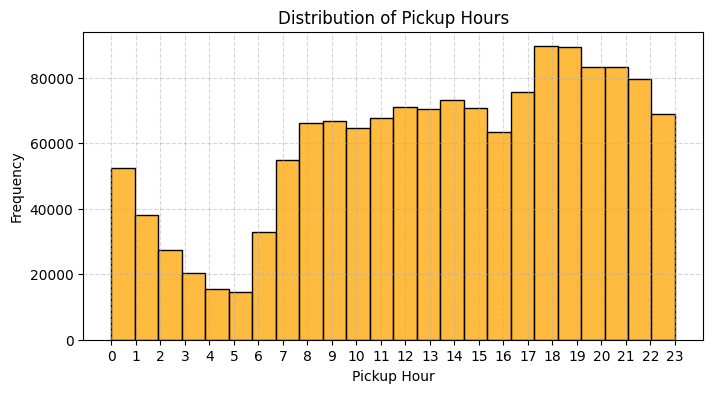

In [37]:
#plot hist for pickup hours
plt.figure(figsize=(8, 4))
sns.histplot(df['pickup_hour'], bins=24, kde=False, color='orange')
plt.title('Distribution of Pickup Hours')
plt.xlabel('Pickup Hour')
plt.ylabel('Frequency')
plt.xticks(range(24), rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

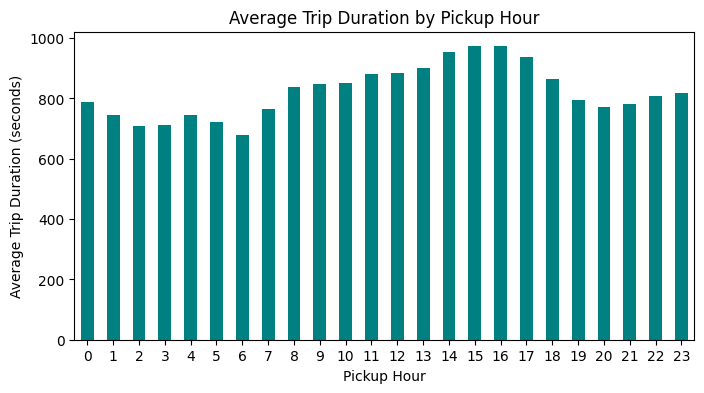

In [38]:
df.groupby('pickup_hour')['trip_duration'].mean().plot(kind='bar', figsize=(8, 4), color='teal')
plt.title('Average Trip Duration by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Trip Duration (seconds)')
plt.xticks(rotation=0)
plt.show()

In [39]:
df['hour_sin'] = np.sin(2 * np.pi * df['pickup_hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['pickup_hour']/24)

In [40]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,manhattan_distance_km,cardinal_direction,hour_sin,hour_cos
600392,id3986264,2,2016-06-25 15:38:55,2016-06-25 15:49:08,5,-73.969627,40.760761,-73.978279,40.777309,N,613,1.979067,15,Saturday,1,5,0,117.601539,11.622579,6,0.395813,6.419995,1,4,2.797188,West,-0.707107,-0.707107


In [41]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,manhattan_distance_km,cardinal_direction,hour_sin,hour_cos
1345711,id1914901,1,2016-06-27 13:24:32,2016-06-27 13:36:40,1,-73.991219,40.732944,-74.008347,40.718864,N,728,2.129419,13,Monday,0,0,0,-140.57812,10.530096,6,2.129419,6.591674,0,0,3.464092,West,-0.258819,-0.965926


#### Trip duration into 3 classes short, medium, long for thresholds [>600>1200] seconds.

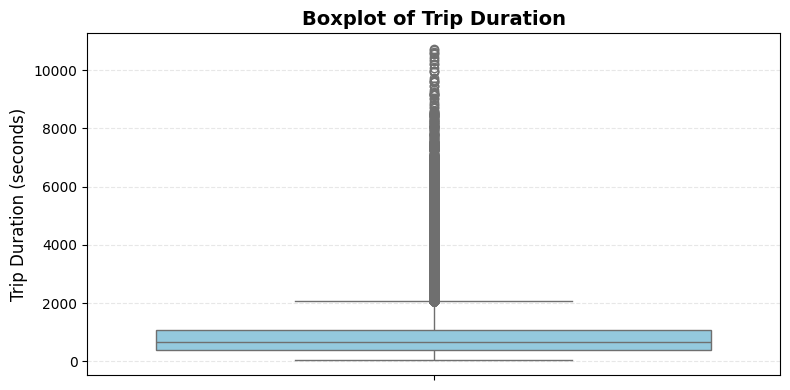

In [42]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, y='trip_duration', color='skyblue')
plt.title('Boxplot of Trip Duration', fontsize=14, fontweight='bold')
plt.ylabel('Trip Duration (seconds)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [43]:
df['trip_duration'].describe().T

count    1.440222e+06
mean     8.424850e+02
std      6.569905e+02
min      6.100000e+01
25%      4.020000e+02
50%      6.660000e+02
75%      1.077000e+03
max      1.073100e+04
Name: trip_duration, dtype: float64

In [44]:
def categorize_duration(seconds):
    if seconds < 600:
        return 'short'
    elif seconds < 1200:
        return 'medium'
    else:
        return 'long'

df['tripduration_cat'] = df['trip_duration'].apply(categorize_duration)

print(df['tripduration_cat'].value_counts())

tripduration_cat
short     638468
medium    509020
long      292734
Name: count, dtype: int64


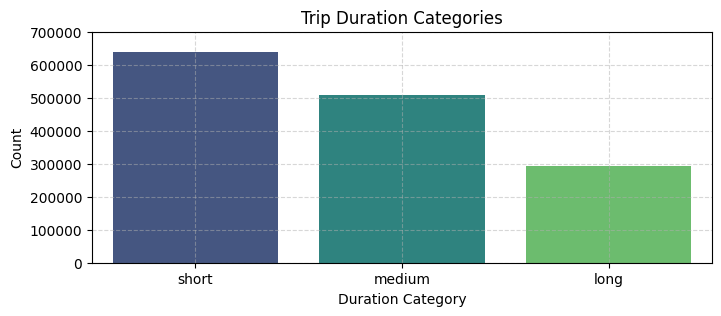

In [45]:
plt.figure(figsize=(8, 3))
sns.barplot(x=df['tripduration_cat'].value_counts().index, y=df['tripduration_cat'].value_counts().values, palette='viridis')
plt.title('Trip Duration Categories')
plt.xlabel('Duration Category')
plt.ylabel('Count')
plt.yticks(np.arange(0, df['tripduration_cat'].value_counts().max() + 90000, 100000))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


- **Stratified Split:** Use `df['tripduration_cat']` as the `stratify` argument in `train_test_split` to ensure proportional class distribution in both splits.
- **Resample Training Only:** Apply `RandomUnderSampler` exclusively to `X_train` and `y_train` to balance the training classes.
- **Preserve Test Set:** Leave the test set completely untouched; **never** apply resampling or modifications to it.
- **Drop Pre-Modeling:** Remove the `tripduration_cat` column from both the resampled training set and the original test set before model training/evaluation.

In [46]:
df.sample(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,manhattan_distance_km,cardinal_direction,hour_sin,hour_cos,tripduration_cat
831578,id3387913,1,2016-05-30 01:56:47,2016-05-30 02:08:03,2,-73.988182,40.723465,-73.966087,40.763653,N,676,4.840855,1,Monday,0,0,0,61.198602,25.779700,5,2.420427,6.517671,0,1,6.913364,West,0.258819,0.965926,medium
163420,id0786061,2,2016-02-15 13:03:09,2016-02-15 13:14:29,1,-73.995262,40.726871,-74.002579,40.741619,N,680,1.751909,13,Monday,0,0,0,116.386930,9.274813,2,1.751909,6.523562,0,1,2.449127,West,-0.258819,-0.965926,medium
677658,id3430900,1,2016-02-22 13:59:52,2016-02-22 14:21:38,1,-73.995804,40.769421,-73.995934,40.720734,N,1306,5.413756,13,Monday,0,0,0,-90.152633,14.923065,2,5.413756,7.175490,1,0,5.418652,West,-0.258819,-0.965926,long


##### Some Featuers needed to be dropped as they were Superseded by other features or was just for EDA, split data and So on.

In [47]:
# df.drop(columns=['pickup_hour','month','direction','tripduration_cat','pickup_day'], inplace=True)

# **Step 3: Feature Selection**
# Overview

We evaluate multiple feature selection techniques spanning:

Filter methods → fast, scalable

Statistical tests → relationship strength

Embedded methods → model-driven

Wrapper methods → optimal subset search

In [48]:
X = df.drop(columns=['trip_duration'])
y = df['trip_duration']

In [49]:
missing_ratio = X.isnull().sum() / len(X)
X = X[missing_ratio[missing_ratio < 0.4].index]

In [50]:
from sklearn.feature_selection import mutual_info_regression, RFECV, VarianceThreshold

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

vt = VarianceThreshold(threshold=0.01)
X = X.select_dtypes(include=['int64','float64'])
X = pd.DataFrame(vt.fit_transform(X), columns=X.columns[vt.get_support()])

In [51]:
numerical_features = [
    'distance_km', 'manhattan_distance_km', 'passenger_count',
    'hour_sin', 'hour_cos',
    'day_of_week', 'is_weekend', 'afternoon_peak', 'month',
    'pickup_cluster', 'dropoff_cluster'
]


In [52]:
# One-hot encode cardinal_direction once, cleanly
df_encoded = pd.get_dummies(
    df[numerical_features + ['cardinal_direction', 'log_trip_duration', 'trip_duration',
                              'tripduration_cat']],
    columns=['cardinal_direction'],
    drop_first=False
)

feature_cols = [c for c in df_encoded.columns
                if c not in ['log_trip_duration', 'trip_duration', 'tripduration_cat']]

X_all = df_encoded[feature_cols]
y_log = df_encoded['log_trip_duration']

# Stratified split using trip duration category to preserve class balance
X_train_full, X_test_full, y_train_log, y_test_log = train_test_split(
    X_all, y_log,
    test_size=0.2,
    random_state=42,
    stratify=df_encoded['tripduration_cat']   # from notebook's existing categorization
)

# Build a training-only dataframe for all selection techniques below
df_train = X_train_full.copy()
df_train['log_trip_duration'] = y_train_log.values
df_train['trip_duration'] = df_encoded.loc[X_train_full.index, 'trip_duration'].values

print(f"Training set : {X_train_full.shape[0]:,} rows")
print(f"Test set     : {X_test_full.shape[0]:,} rows")
print(f"Features     : {len(feature_cols)}")
print("\nAll feature selection techniques below use df_train only.")



Training set : 1,152,177 rows
Test set     : 288,045 rows
Features     : 15

All feature selection techniques below use df_train only.


In [53]:
print("Encoded feature columns ready for all techniques:")
print(feature_cols)

Encoded feature columns ready for all techniques:
['distance_km', 'manhattan_distance_km', 'passenger_count', 'hour_sin', 'hour_cos', 'day_of_week', 'is_weekend', 'afternoon_peak', 'month', 'pickup_cluster', 'dropoff_cluster', 'cardinal_direction_East', 'cardinal_direction_North', 'cardinal_direction_South', 'cardinal_direction_West']


**Technique 1 — Correlation Analysis (Filter Method)**

Best for: Quickly removing redundant numerical features.
Why it fits this project: `distance_km` and `manhattan_distance_km` were both engineered to capture trip length. A correlation check will confirm whether both are necessary or if one is redundant.

In [54]:
target = 'log_trip_duration'
corr_matrix = df_train[feature_cols + [target]].corr()
target_corr = corr_matrix[target].drop(target)

# # ── Plot heatmap ──────────────────────────────────────────────────────────────
# plt.figure(figsize=(12, 9))
# sns.heatmap(
#     corr_matrix,
#     annot=True, fmt='.2f',
#     cmap='coolwarm', center=0,
#     linewidths=0.5
# )
# plt.title('Pearson Correlation Matrix — NYC Taxi Features', fontsize=14)
# plt.tight_layout()
# plt.show()

# ── Identify highly correlated feature pairs (threshold > 0.85) ──────────────
threshold = 0.85
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 3)
            ))

print("Highly Correlated Pairs (|r| > 0.85):")
for f1, f2, r in high_corr_pairs:
    print(f"  {f1}  <-->  {f2}  (r = {r})")

# ── Correlation with target (feature relevance ranking) ──────────────────────
target_corr = corr_matrix[target].drop(target).abs().sort_values(ascending=False)
print("\nFeature Correlation with trip_duration (absolute):")
print(target_corr.to_string())

Highly Correlated Pairs (|r| > 0.85):
  distance_km  <-->  manhattan_distance_km  (r = 0.992)

Feature Correlation with trip_duration (absolute):
distance_km                 0.663984
manhattan_distance_km       0.643324
dropoff_cluster             0.073766
hour_cos                    0.062071
afternoon_peak              0.060934
is_weekend                  0.059691
month                       0.052552
hour_sin                    0.051372
pickup_cluster              0.047887
day_of_week                 0.030854
passenger_count             0.014380
cardinal_direction_North    0.004314
cardinal_direction_West     0.004232
cardinal_direction_East     0.002822
cardinal_direction_South    0.000067


**Technique 2 — Mutual Information (Filter Method)**

Best for: Detecting non-linear relationships that Pearson correlation misses.
Why it fits this project: The relationship between `pickup_hour` and `trip_duration` is non-linear. Mutual Information captures this without assuming linearity.

In [55]:
# Handle any remaining NaN
X_mi = df_train[feature_cols].copy()
X_mi = X_mi.replace([np.inf, -np.inf], np.nan).fillna(X_mi.median())
y_mi = df_train['log_trip_duration']

# ── Compute Mutual Information ────────────────────────────────────────────────
mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

# # ── Plot ──────────────────────────────────────────────────────────────────────
# plt.figure(figsize=(10, 6))
# mi_series.plot(kind='barh', color='steelblue', edgecolor='black')
# plt.xlabel('Mutual Information Score')
# plt.title('Mutual Information — Feature vs. trip_duration', fontsize=13)
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

print("\nMutual Information Scores (sorted):")
print(mi_series.to_string())


Mutual Information Scores (sorted):
distance_km                 0.548041
manhattan_distance_km       0.521726
pickup_cluster              0.070074
dropoff_cluster             0.047806
hour_cos                    0.006342
hour_sin                    0.005200
afternoon_peak              0.003415
month                       0.003393
is_weekend                  0.002867
day_of_week                 0.002279
cardinal_direction_South    0.001550
cardinal_direction_East     0.001482
passenger_count             0.000433
cardinal_direction_West     0.000070
cardinal_direction_North    0.000000


**Technique 3 — Random Forest Feature Importance (Embedded Method)**

Best for: Ranking all features simultaneously using a tree-based model — no linearity assumption.
Why it fits : The notebook uses KMeans clusters and cyclical time features. A Random Forest naturally handles mixed-type features and gives reliable importance scores that reflect interaction effects (e.g., `afternoon_peak` × `distance_km`).

In [56]:
X_rf = df_train[feature_cols]
y_rf = df_train['log_trip_duration']

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

# ── Train Random Forest (lightweight config for feature selection) ────────────
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,           # Limit depth to speed up
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# ── Extract & plot importances ────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X_rf.columns)
importances = importances.sort_values(ascending=False)

# plt.figure(figsize=(10, 7))
# importances.plot(kind='barh', color='darkorange', edgecolor='black')
# plt.xlabel('Feature Importance (Gini Impurity Reduction)')
# plt.title('Random Forest Feature Importances — NYC Taxi', fontsize=13)
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

# ── Print cumulative importance to find minimal feature set ──────────────────
cumulative = importances.cumsum()
threshold_95 = importances[cumulative <= 0.95]
print(f"\nFeatures capturing 95% of importance ({len(threshold_95)} features):")
print(threshold_95.to_string())


Features capturing 95% of importance (3 features):
distance_km        0.879646
hour_cos           0.040065
dropoff_cluster    0.026964


**Technique 4 — Recursive Feature Elimination with Cross-Validation (RFECV)**

Best for: Automatically finding the optimal number of features via cross-validation.
Why it fits this project: The notebook has potential redundancy between `distance_km` / `manhattan_distance_km `and between `pickup_hour `/ `hour_sin` / `hour_cos`. RFECV systematically prunes the weakest features while measuring model performance at each step

In [57]:
X_rfecv = df_train[feature_cols]
y_rfecv = df_train['log_trip_duration']

scaler_rfecv = StandardScaler()
X_scaled = scaler_rfecv.fit_transform(X_rfecv)

estimator = Ridge(alpha=1.0)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=cv,
    scoring='neg_mean_squared_error',
    min_features_to_select=3,
    n_jobs=-1,
    verbose=1
)
rfecv.fit(X_scaled, y_rfecv)

print(f"\nOptimal number of features: {rfecv.n_features_}")
selected_features = X_rfecv.columns[rfecv.support_].tolist()
print(f"Selected features: {selected_features}")

# plt.figure(figsize=(9, 5))
# plt.plot(
#     range(rfecv.min_features_to_select,
#           len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
#     -rfecv.cv_results_['mean_test_score'],
#     marker='o', color='purple'
# )
# plt.xlabel('Number of Features Selected')
# plt.ylabel('CV Mean Squared Error (on log scale)')
# plt.title('RFECV — Optimal Feature Count (target: log_trip_duration)', fontsize=13)
# plt.axvline(rfecv.n_features_, linestyle='--', color='red',
#             label=f'Optimal = {rfecv.n_features_}')
# plt.legend()
# plt.tight_layout()
# plt.show()

Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.

Optimal number of features: 12
Selected features: ['distance_km', 'manhattan_distance_km', 'passenger_count', 'hour_sin', 'hour_cos', 'day_of_week', 'is_weekend', 'afternoon_peak', 'month', 'pickup_cluster', 'dropoff_cluster', 'cardinal_direction_West']


**Technique 5 — Permutation Importance (Model-Agnostic, Post-Fit)**

Best for: Validating feature importance on the test set — not biased by training data.
Why it fits this project: The notebook's engineered features (e.g., `pickup_cluste`r, `afternoon_peak`) may appear important on training data but actually overfit. Permutation Importance shuffles each feature on the held-out test set and measures the performance drop — a more honest evaluation.

In [58]:
X_perm = df_train[feature_cols]
y_perm = df_train['log_trip_duration']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_perm, y_perm, test_size=0.2, random_state=42
)

# ── Fit a Gradient Boosting model ─────────────────────────────────────────────
gb = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train_p, y_train_p)

# ── Compute Permutation Importance on TEST SET ────────────────────────────────
perm_result = permutation_importance(
    gb, X_test_p, y_test_p,
    n_repeats=10,           # Shuffle each feature 10 times → stable estimate
    random_state=42,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

perm_importances = pd.Series(
    perm_result.importances_mean,
    index=X_perm.columns
).sort_values(ascending=False)

perm_std = pd.Series(perm_result.importances_std, index=X_perm.columns)

# ── Plot with error bars ──────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(10, 7))
# sorted_idx = perm_importances.sort_values().index
# ax.barh(
#     sorted_idx,
#     perm_importances[sorted_idx],
#     xerr=perm_std[sorted_idx],
#     color='teal', edgecolor='black', alpha=0.8
# )
# ax.set_xlabel('Mean Permutation Importance (MSE increase when shuffled)')
# ax.set_title('Permutation Importance on Test Set — NYC Taxi', fontsize=13)
# plt.tight_layout()
# plt.show()

# ── Flag features with negative or near-zero importance ──────────────────────
weak_features = perm_importances[perm_importances <= 0].index.tolist()
print(f"\n  Features with zero/negative permutation importance (consider dropping):")
print(weak_features if weak_features else "None — all features contribute positively.")


  Features with zero/negative permutation importance (consider dropping):
['cardinal_direction_North', 'cardinal_direction_South']


In [59]:
features_to_drop = perm_importances[perm_importances <= 0].index.tolist()

print("Features dropped due to zero/negative permutation importance:")
print(features_to_drop if features_to_drop else "None — all features pass.")

# Remove them from our master feature list
final_features = [f for f in feature_cols if f not in features_to_drop]

print(f"\nFinal approved feature list ({len(final_features)} features):")
for f in final_features:
    print(f"  ✓ {f}")

Features dropped due to zero/negative permutation importance:
['cardinal_direction_North', 'cardinal_direction_South']

Final approved feature list (13 features):
  ✓ distance_km
  ✓ manhattan_distance_km
  ✓ passenger_count
  ✓ hour_sin
  ✓ hour_cos
  ✓ day_of_week
  ✓ is_weekend
  ✓ afternoon_peak
  ✓ month
  ✓ pickup_cluster
  ✓ dropoff_cluster
  ✓ cardinal_direction_East
  ✓ cardinal_direction_West


# **Step 4 — Feature Selection Consolidation & Final Dataset Construction**
Objective

After applying multiple feature selection methods, we now:

Combine all importance signals

Build a unified feature ranking

Define stable feature subsets

Select final feature set for modeling

Validate that selection improves performance

**4.1 Build Unified Feature Importance Table**

We combine:

Mutual Information (non-linear signal)
Random Forest importance (interaction-aware)
Permutation importance (most reliable)

In [60]:
# Ensure all indices align
feature_scores = pd.DataFrame(index=feature_cols)

feature_scores['mutual_info'] = mi_series.reindex(feature_scores.index)
feature_scores['rf_importance'] = importances.reindex(feature_scores.index)
feature_scores['permutation_importance'] = perm_importances.reindex(feature_scores.index)

# Fill missing values (if any feature missing from a method)
feature_scores = feature_scores.fillna(0)

# Normalize each column to [0, 1]
feature_scores_normalized = feature_scores.apply(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
)

# Final aggregated score
feature_scores_normalized['final_score'] = feature_scores_normalized.mean(axis=1)

# Sort features
feature_ranking = feature_scores_normalized.sort_values(
    'final_score',
    ascending=False
)

feature_ranking

,mutual_info,rf_importance,permutation_importance,final_score
distance_km,1.000000,1.000000,1.000000e+00,1.000000
manhattan_distance_km,0.951984,0.004404,1.302865e-02,0.323139
dropoff_cluster,0.087230,0.030654,2.952381e-02,0.049136
pickup_cluster,0.127863,0.002762,4.849423e-03,0.045158
hour_cos,0.011572,0.045547,7.034790e-02,0.042489
hour_sin,0.009489,0.027632,3.088201e-02,0.022668
day_of_week,0.004159,0.017667,1.959474e-02,0.013807
is_weekend,0.005230,0.006508,2.967176e-03,0.004902
month,0.006191,0.001487,3.439305e-03,0.003706
afternoon_peak,0.006231,0.000046,2.681518e-04,0.002182


**4.2 Define Feature Subsets**

In [61]:
# Top features
core_features = feature_ranking.head(6).index.tolist()

# Medium set
extended_features = feature_ranking.head(10).index.tolist()

# Full set
all_features = feature_ranking.index.tolist()

print("Core Features:", core_features)
print("Extended Features:", extended_features)

Core Features: ['distance_km', 'manhattan_distance_km', 'dropoff_cluster', 'pickup_cluster', 'hour_cos', 'hour_sin']
Extended Features: ['distance_km', 'manhattan_distance_km', 'dropoff_cluster', 'pickup_cluster', 'hour_cos', 'hour_sin', 'day_of_week', 'is_weekend', 'month', 'afternoon_peak']


# **Step 5 — Model Evaluation Across Feature Sets**

          RMSE (log)      R²  RMSE (sec)
core          0.3828  0.7227       350.0
extended      0.3691  0.7422       332.5
all           0.3690  0.7423       332.5


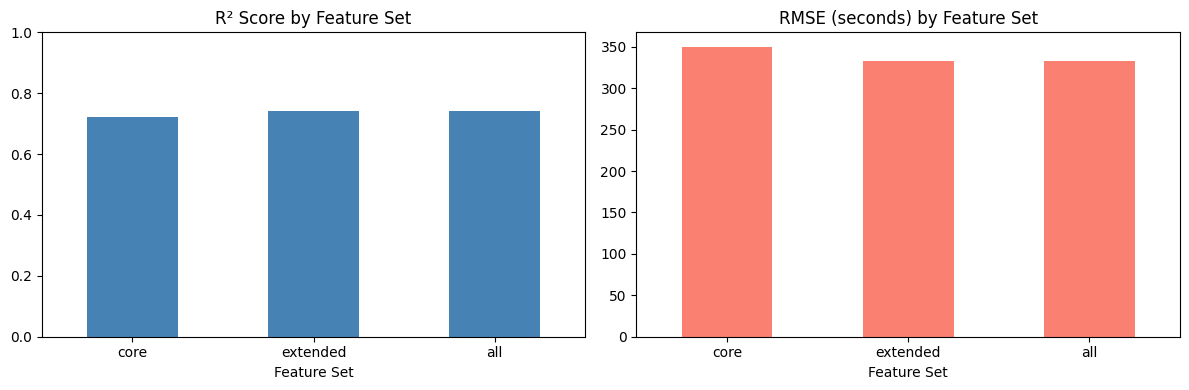


Best feature set: extended


In [62]:
def evaluate_features(feature_list, X_train, X_test, y_train, y_test):
    """Evaluate a feature subset using the pre-split train/test sets."""
    Xtr = X_train[feature_list].copy()
    Xte = X_test[feature_list].copy()

    # Clean infinities/NaN
    Xtr = Xtr.replace([np.inf, -np.inf], np.nan).fillna(Xtr.median())
    Xte = Xte.replace([np.inf, -np.inf], np.nan).fillna(Xte.median())

    model = RandomForestRegressor(
        n_estimators=150,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    rmse        = np.sqrt(mean_squared_error(y_test, preds))
    r2          = r2_score(y_test, preds)
    rmse_seconds = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(preds)))

    return rmse, r2, rmse_seconds


# ── Evaluation loop ───────────────────────────────────────────────────────────
# Use X_train_full / X_test_full from the initial split (Step 3 opening cell)
results = {}
for name, features in {
    "core":     core_features,
    "extended": extended_features,
    "all":      all_features
}.items():
    rmse, r2, rmse_sec = evaluate_features(
        features,
        X_train_full, X_test_full,
        y_train_log,  y_test_log
    )
    results[name] = {
        "RMSE (log)": round(rmse, 4),
        "R²":          round(r2, 4),
        "RMSE (sec)": round(rmse_sec, 1)
    }

results_df = pd.DataFrame(results).T
print(results_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results_df['R²'].plot(kind='bar', ax=axes[0], color='steelblue',
                       title='R² Score by Feature Set', ylim=(0, 1))
results_df['RMSE (sec)'].plot(kind='bar', ax=axes[1], color='salmon',
                               title='RMSE (seconds) by Feature Set')
for ax in axes:
    ax.set_xlabel('Feature Set')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

best_set = results_df['RMSE (sec)'].idxmin()
print(f"\nBest feature set: {best_set}")

In [63]:
# ── 6.1  Lock in the winning feature set ─────────────────────────────────────
winning_features = {
    "core":     core_features,
    "extended": extended_features,
    "all":      all_features
}[best_set]

print(f"Winning feature set: '{best_set}'")
print(f"Features ({len(winning_features)}):")
for f in winning_features:
    print(f"  • {f}")

Winning feature set: 'extended'
Features (10):
  • distance_km
  • manhattan_distance_km
  • dropoff_cluster
  • pickup_cluster
  • hour_cos
  • hour_sin
  • day_of_week
  • is_weekend
  • month
  • afternoon_peak


In [64]:
# ── 6.2  Build final train / test matrices ───────────────────────────────────

X_train_final = X_train_full[winning_features].copy()
X_test_final  = X_test_full[winning_features].copy()

y_train_final = y_train_log.copy()   # log_trip_duration
y_test_final  = y_test_log.copy()

print(f"X_train_final shape : {X_train_final.shape}")
print(f"X_test_final  shape : {X_test_final.shape}")
X_train_final.sample(3)

X_train_final shape : (1152177, 10)
X_test_final  shape : (288045, 10)


,distance_km,manhattan_distance_km,dropoff_cluster,pickup_cluster,hour_cos,hour_sin,day_of_week,is_weekend,month,afternoon_peak
1194771,1.345709,2.195915,0,0,0.866025,0.500000,6,1,1,0
359797,1.742553,2.879757,0,0,-0.707107,-0.707107,5,1,3,0
1307350,4.504034,5.343704,4,4,-0.707107,0.707107,5,1,4,0


In [65]:
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_final)   # fit on train ONLY
X_test_scaled  = scaler_final.transform(X_test_final)        # transform test with same params

# Wrap back in DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=winning_features, index=X_train_final.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=winning_features, index=X_test_final.index)

print("Scaling applied. Sample of scaled training data:")
X_train_scaled.describe().T[['mean', 'std', 'min', 'max']].round(3)

Scaling applied. Sample of scaled training data:


,mean,std,min,max
distance_km,-0.0,1.0,-0.855,23.855
manhattan_distance_km,-0.0,1.0,-0.817,23.198
dropoff_cluster,0.0,1.0,-1.039,1.576
pickup_cluster,-0.0,1.0,-1.039,1.699
hour_cos,-0.0,1.0,-1.295,1.535
hour_sin,0.0,1.0,-1.186,1.787
day_of_week,-0.0,1.0,-1.561,1.509
is_weekend,0.0,1.0,-0.632,1.583
month,0.0,1.0,-1.497,1.478
afternoon_peak,0.0,1.0,-0.336,2.978


In [66]:
# ── 6.4  Sanity check — no leakage, no NaN ───────────────────────────────────

assert X_train_scaled.isnull().sum().sum() == 0, "NaN found in training set!"
assert X_test_scaled.isnull().sum().sum()  == 0, "NaN found in test set!"
assert 'log_trip_duration' not in X_train_scaled.columns, "Target leaked into features!"
assert 'trip_duration'     not in X_train_scaled.columns, "Raw target leaked into features!"

print("✓ No NaN values")
print("✓ No target leakage")
print(f"✓ Training rows : {len(X_train_scaled):,}")
print(f"✓ Test rows     : {len(X_test_scaled):,}")
print(f"✓ Features      : {len(winning_features)}")

✓ No NaN values
✓ No target leakage
✓ Training rows : 1,152,177
✓ Test rows     : 288,045
✓ Features      : 10


In [69]:
# ── 7. LightGBM Model ─────────────────────────────────────────

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train_scaled, y_train_final)


y_pred_lgb = lgb_model.predict(X_test_scaled)


from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test_final, y_pred_lgb)
rmse = np.sqrt(mse)

r2 = r2_score(y_test_final, y_pred_lgb)

print("LightGBM RMSE:", rmse)
print("LightGBM R2:", r2)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063689 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 584
[LightGBM] [Info] Number of data points in the train set: 1152177, number of used features: 10
[LightGBM] [Info] Start training from score 6.482523
LightGBM RMSE: 0.3628553827011795
LightGBM R2: 0.750838955285445


In [71]:
# ── 7.1  Evaluate from LightGBM ───────────────────────────────────

y_pred_real = np.expm1(y_pred_lgb)
y_test_real = np.expm1(y_test_final)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)

r2 = r2_score(y_test_real, y_pred_real)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 325.29179654747446
R2: 0.7564960346673635


<Figure size 1000x600 with 0 Axes>

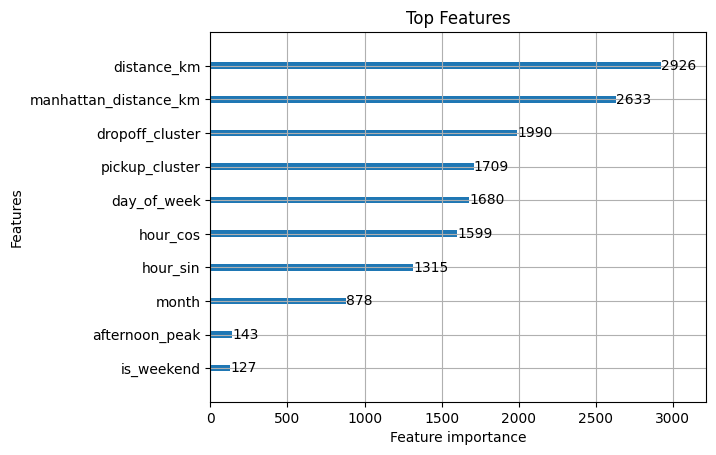

In [72]:
# ── 7.1  Feature Importance from LightGBM ───────────────────────────────────
plt.figure(figsize=(10,6))
lgb.plot_importance(lgb_model, max_num_features=10)
plt.title("Top Features")
plt.show()


# **Step 6 —Final Model Training using Best Features**


In [73]:
best_set = results_df['RMSE (sec)'].idxmin()

In [74]:
# Select best feature list
if best_set == "core":
    best_features = core_features
elif best_set == "extended":
    best_features = extended_features
else:
    best_features = all_features

print("Using features:", best_set)

Using features: extended


In [ ]:
# 8.1 ___ Prepare Data with Best Features _________________
X_train_best = X_train_full[best_features].copy()
X_test_best = X_test_full[best_features].copy()

# Clean data (important)
X_train_best = X_train_best.replace([np.inf, -np.inf], np.nan).fillna(X_train_best.median())
X_test_best = X_test_best.replace([np.inf, -np.inf], np.nan).fillna(X_test_best.median())

In [76]:
#8.2 __lightGBM with best features____________________
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(X_train_best, y_train_log)

y_pred_lgb = lgb_model.predict(X_test_best)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 577
[LightGBM] [Info] Number of data points in the train set: 1152177, number of used features: 10
[LightGBM] [Info] Start training from score 6.482523


In [77]:
# 8.3 ___ Evaluate lightGBM __________________________
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_lgb_real = np.expm1(y_pred_lgb)
y_test_real = np.expm1(y_test_log)

mse_lgb = mean_squared_error(y_test_real, y_pred_lgb_real)
rmse_lgb = np.sqrt(mse_lgb)

r2_lgb = r2_score(y_test_real, y_pred_lgb_real)

print("LightGBM RMSE:", rmse_lgb)
print("LightGBM R2:", r2_lgb)

LightGBM RMSE: 325.3635428911705
LightGBM R2: 0.7563886083748964


In [78]:
# 8.4 ___ Random Forest Model __________________________
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_best, y_train_log)

y_pred_rf = rf_model.predict(X_test_best)

In [79]:
# 8.5 ___ Evaluate Random Forest __________________________
y_pred_rf_real = np.expm1(y_pred_rf)

mse_rf = mean_squared_error(y_test_real, y_pred_rf_real)
rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test_real, y_pred_rf_real)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 325.6549817937487
Random Forest R2: 0.7559519913307334


In [80]:
# 8.6 ___ Final Model Comparison __________________________
import pandas as pd

final_results = pd.DataFrame({
    "Model": ["LightGBM", "Random Forest"],
    "RMSE": [rmse_lgb, rmse_rf],
    "R2": [r2_lgb, r2_rf]
})

print(final_results)

           Model        RMSE        R2
0       LightGBM  325.363543  0.756389
1  Random Forest  325.654982  0.755952


<Figure size 800x500 with 0 Axes>

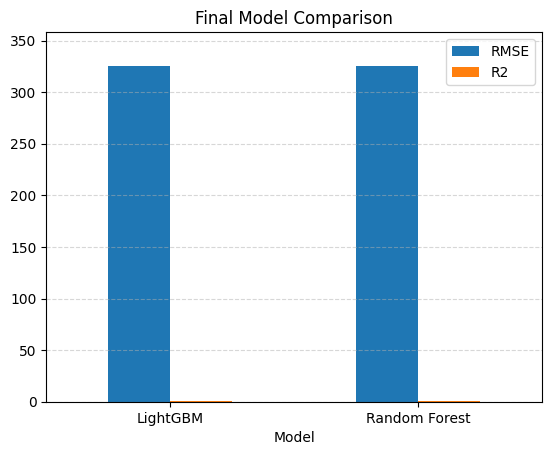

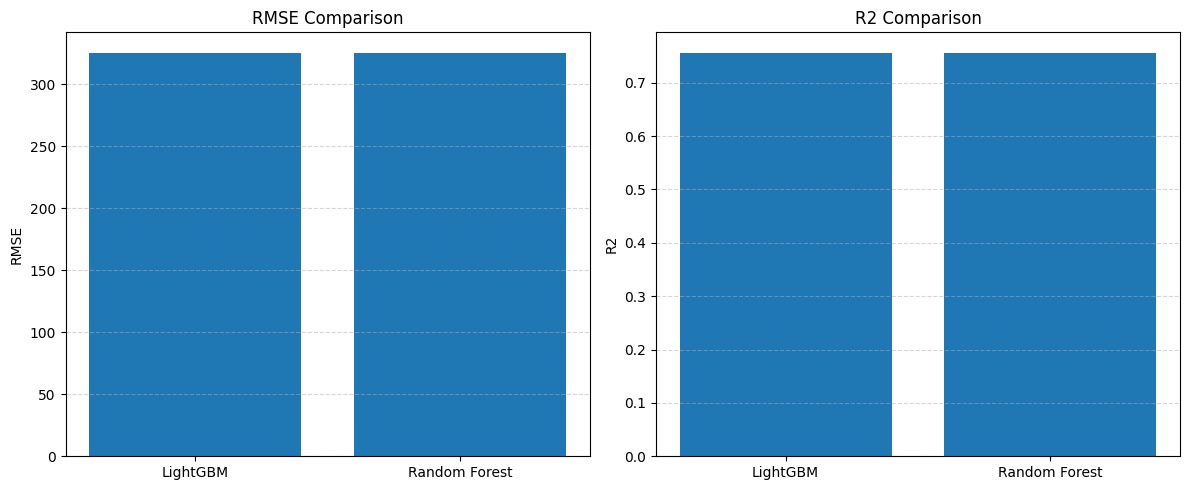

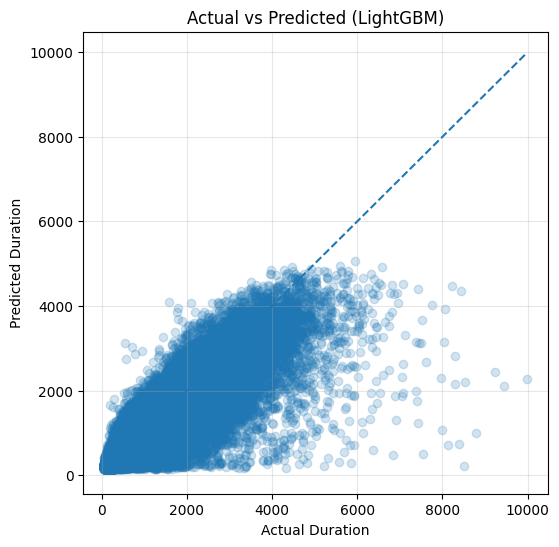

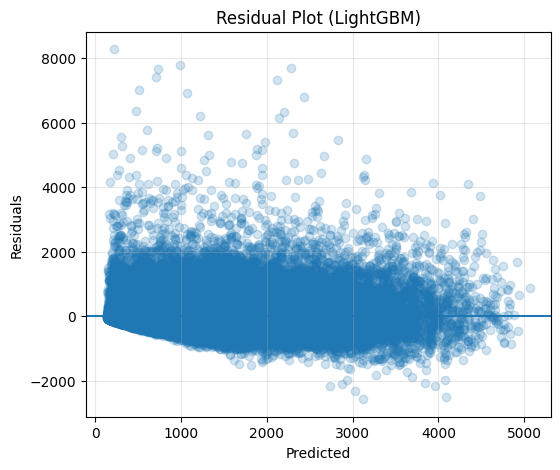

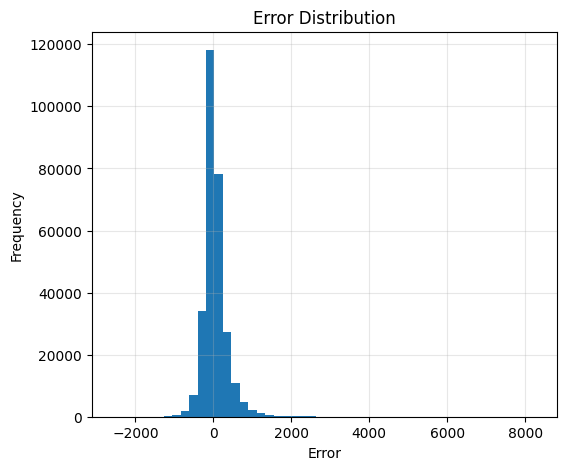

In [91]:
# ── 8.7 Visualization ─────────────────────────────────────────

import matplotlib.pyplot as plt

# ── Combined Model Comparison  ─────────────────────────

plt.figure(figsize=(8,5))

ax = final_results.set_index("Model")[["RMSE", "R2"]].plot(kind="bar")

plt.title("Final Model Comparison")
plt.xticks(rotation=0)

# نخلي R2 واضح شوية
plt.ylim(0, final_results["RMSE"].max() * 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()
# ── Model Comparison  ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# RMSE Plot
axes[0].bar(final_results["Model"], final_results["RMSE"])
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# R2 Plot
axes[1].bar(final_results["Model"], final_results["R2"])
axes[1].set_title("R2 Comparison")
axes[1].set_ylabel("R2")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ── Actual vs Predicted  ─────────────────────────

plt.figure(figsize=(6,6))
plt.scatter(y_test_real, y_pred_real, alpha=0.2)

plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Actual vs Predicted (LightGBM)")

# Ideal line
plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    linestyle='--'
)

plt.grid(alpha=0.3)
plt.show()


# ── Residual Plot  ─────────────────────────

residuals = y_test_real - y_pred_real

plt.figure(figsize=(6,5))
plt.scatter(y_pred_real, residuals, alpha=0.2)

plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot (LightGBM)")

plt.grid(alpha=0.3)
plt.show()


# ── Error Distribution ─────────────────────────

plt.figure(figsize=(6,5))
plt.hist(residuals, bins=50)

plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.show()